In [1]:
print(5)

5


In [2]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# Project paths
BASE_DIR = Path("../data")

TRAIN_DIR = BASE_DIR / "train"
VAL_DIR = BASE_DIR / "val"
TEST_DIR = BASE_DIR / "test"

# Image settings
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

print("Train directory:", TRAIN_DIR)
print("Validation directory:", VAL_DIR)
print("Test directory:", TEST_DIR)

Train directory: ..\data\train
Validation directory: ..\data\val
Test directory: ..\data\test


In [6]:
# Class names

class_names = sorted([folder.name for folder in TRAIN_DIR.iterdir() if folder.is_dir()])

print("Number of classes:", len(class_names))
print("Classes:")
for cls in class_names:
    print("-", cls)

Number of classes: 11
Classes:
- animal fish
- animal fish bass
- fish sea_food black_sea_sprat
- fish sea_food gilt_head_bream
- fish sea_food hourse_mackerel
- fish sea_food red_mullet
- fish sea_food red_sea_bream
- fish sea_food sea_bass
- fish sea_food shrimp
- fish sea_food striped_red_mullet
- fish sea_food trout


In [7]:
# counting images

def count_images(directory):
    counts = {}
    for class_dir in sorted(directory.iterdir()):
        if class_dir.is_dir():
            counts[class_dir.name] = len(list(class_dir.glob("*")))
    return counts

train_counts = count_images(TRAIN_DIR)
val_counts = count_images(VAL_DIR)
test_counts = count_images(TEST_DIR)

print("Training images:", sum(train_counts.values()))
print("Validation images:", sum(val_counts.values()))
print("Test images:", sum(test_counts.values()))

Training images: 6225
Validation images: 1092
Test images: 3187


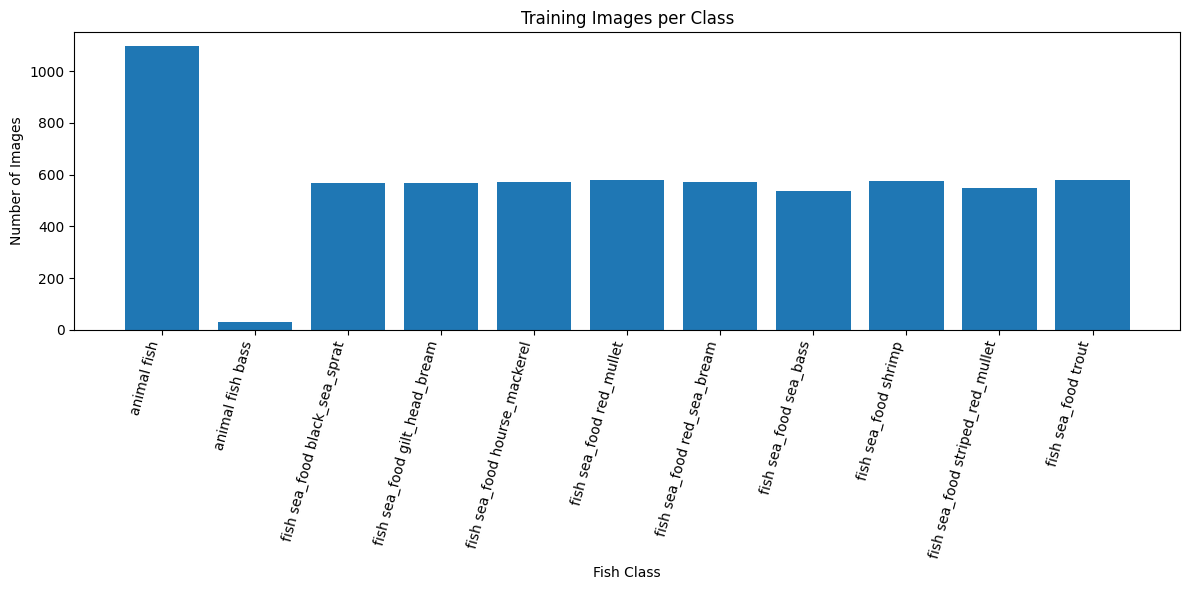

In [8]:
# Checking the class distribution

plt.figure(figsize=(12, 6))
plt.bar(train_counts.keys(), train_counts.values())
plt.xticks(rotation=75, ha="right")
plt.title("Training Images per Class")
plt.xlabel("Fish Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

In [11]:
# Creating data generators

train_datagen = ImageDataGenerator(
    rescale = 1 / 255,
    rotation_range = 20,
    zoom_range = 0.2,
    horizontal_flip = True,
    width_shift_range = 0.1,
    height_shift_range = 0.1
)

val_test_datagen = ImageDataGenerator(
    rescale = 1. / 255
)

In [12]:
# Loading Training, Validation and Test data

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 6225 images belonging to 11 classes.
Found 1092 images belonging to 11 classes.
Found 3187 images belonging to 11 classes.


In [13]:
# Storing Class labels

class_indices = train_generator.class_indices
class_labels = list(class_indices.keys())

print("Class indices:")
print(class_indices)

Class indices:
{'animal fish': 0, 'animal fish bass': 1, 'fish sea_food black_sea_sprat': 2, 'fish sea_food gilt_head_bream': 3, 'fish sea_food hourse_mackerel': 4, 'fish sea_food red_mullet': 5, 'fish sea_food red_sea_bream': 6, 'fish sea_food sea_bass': 7, 'fish sea_food shrimp': 8, 'fish sea_food striped_red_mullet': 9, 'fish sea_food trout': 10}


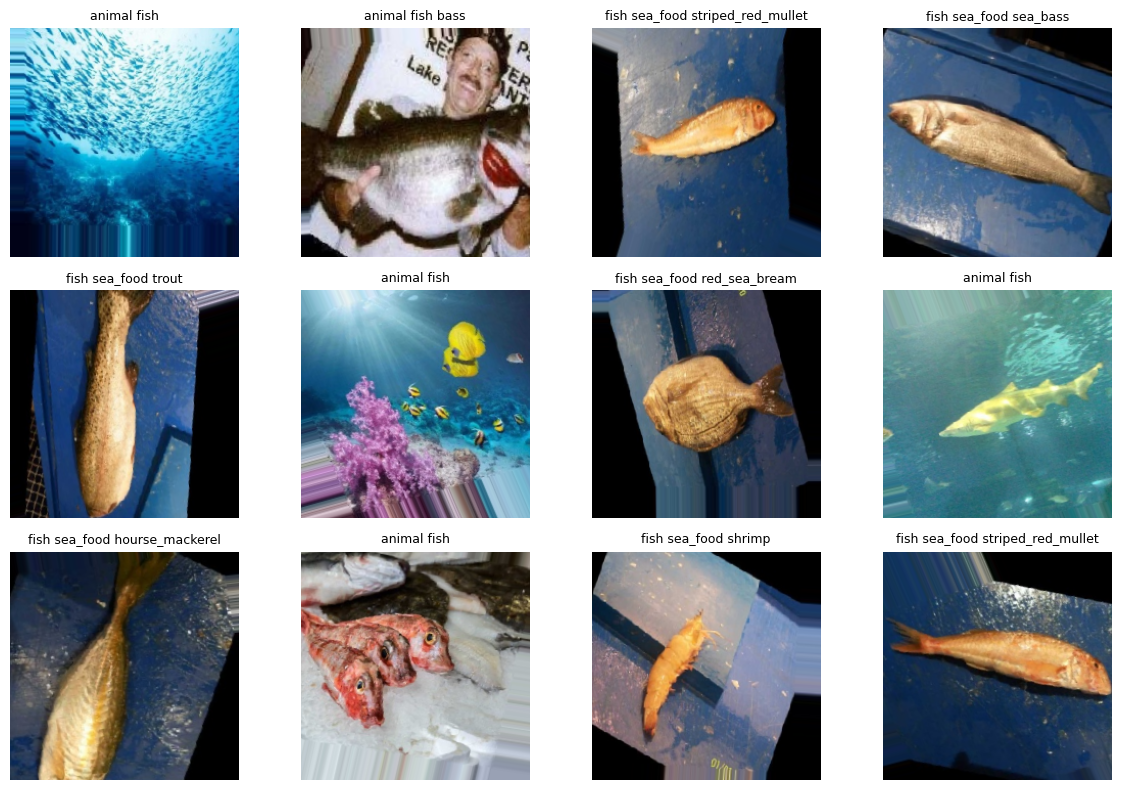

In [14]:
# Displaying sample training images

images, labels = next(train_generator)

plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i])
    label_index = np.argmax(labels[i])
    plt.title(class_labels[label_index], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In this notebook, we have:

 - verified the dataset structure
 - checked all fish classes
 - counted images in each split
 - visualized class distribution
 - created augmented training data
 - created validation and test generators
 - prepared the label mapping

In [ ]:
# Checking the distribution of classes

import pandas as pd

distribution_df = pd.DataFrame({
    "train": train_counts,
    "val": val_counts,
    "test": test_counts
})

distribution_df

,train,val,test
animal fish,1096,187,520
animal fish bass,30,10,13
fish sea_food black_sea_sprat,569,105,298
fish sea_food gilt_head_bream,566,94,305
fish sea_food hourse_mackerel,573,97,286
fish sea_food red_mullet,579,90,291
fish sea_food red_sea_bream,571,113,273
fish sea_food sea_bass,538,97,327
fish sea_food shrimp,576,100,289
fish sea_food striped_red_mullet,547,101,293


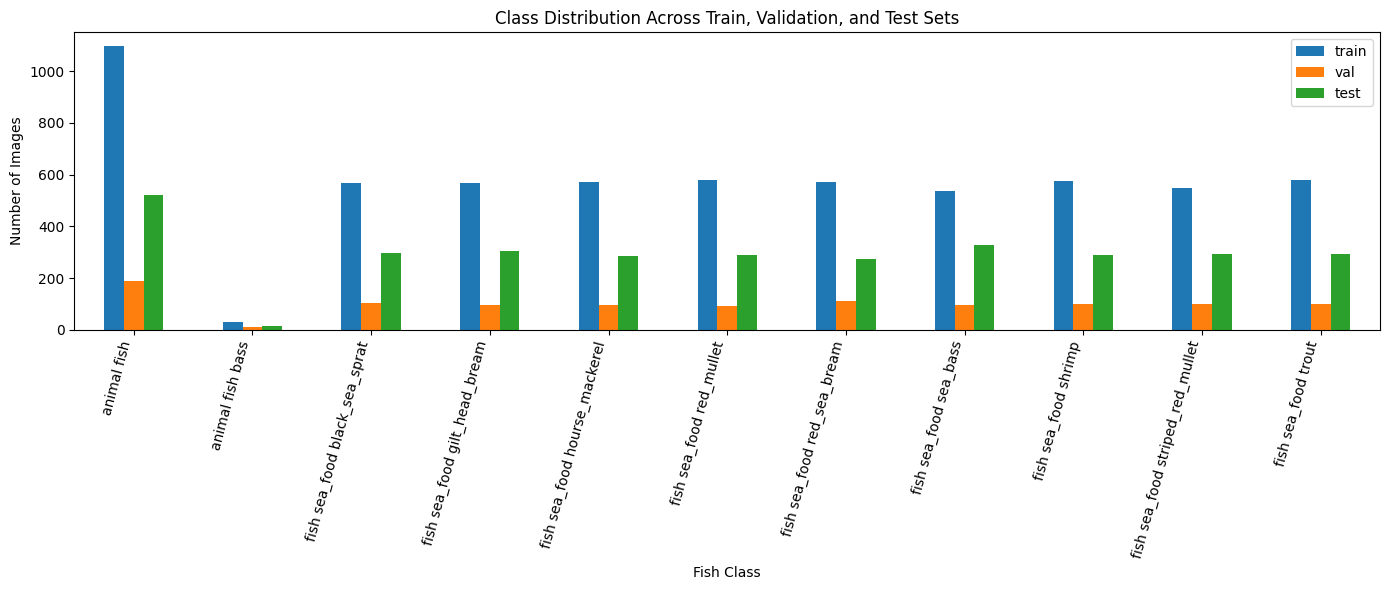

In [16]:
distribution_df.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Class Distribution Across Train, Validation, and Test Sets")
plt.xlabel("Fish Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# Computing class weights

from sklearn.utils.class_weight import compute_class_weight

# Get class labels for every training image
train_class_labels = train_generator.classes

# Compute balanced class weights
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_class_labels),
    y=train_class_labels
)

# Convert to dictionary format required by Keras
class_weights = {
    i: weight for i, weight in enumerate(class_weights_array)
}

print("Class weights:")
for class_index, weight in class_weights.items():
    print(f"{class_labels[class_index]}: {weight:.2f}")

Class weights:
animal fish: 0.52
animal fish bass: 18.86
fish sea_food black_sea_sprat: 0.99
fish sea_food gilt_head_bream: 1.00
fish sea_food hourse_mackerel: 0.99
fish sea_food red_mullet: 0.98
fish sea_food red_sea_bream: 0.99
fish sea_food sea_bass: 1.05
fish sea_food shrimp: 0.98
fish sea_food striped_red_mullet: 1.03
fish sea_food trout: 0.98
